# 07 · Better enclosures: derivatives and adaptive subdivision

**Time:** 100–120 minutes. **Prerequisites:** Lecture 06 and the mean value theorem.
**Lab:** [Improve and audit an enclosure](../labs/lab07_better_enclosures.ipynb).

Objectives: derive a mean-value enclosure, exploit certified monotonicity,
combine valid bounds, and distinguish a local refinement target from a global
range width. Derivatives are supplied explicitly; automatic differentiation
is the next teaching block.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'notebooks'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.enclosures import (mean_value, combined_enclosure, monotone_enclosure,
                           adaptive_range)
from vc.arb_bridge import evaluate_ball

## THEORY · Derive the mean-value enclosure

Assume f is continuously differentiable on an interval containing X=[a,b].
Choose m in X, let C enclose f(m), and let D enclose f′ at every point of X.
Then

$$f(X)\subseteq C+D(X-[m,m]).$$

**Proof.** For every x in X different from m, the mean value theorem gives
f(x)=f(m)+f′(ξ)(x−m) for some ξ between m and x, hence in X. Enclose each
factor using C, D, and X−[m,m]. For x=m the inclusion follows directly.

We take the exact rational midpoint. A machine evaluation of f(m) is still an
enclosure, not an assumed exact point value. An approximate derivative at the
midpoint alone is not a derivative bound over X.

In [3]:
def f(X):
    return X * (1 - X)

def df(X):
    return 1 - 2*X

def centered_bound(evaluate, derivative, domain):
    center = Interval(domain.midpoint())
    center_value = evaluate(center)
    slope_bounds = derivative(domain)
    displacement = domain - center
    return center_value + slope_bounds * displacement

domain = Interval("1/4", "3/4")
print("Natural:", f(domain))
print("Mean value:", centered_bound(f, df, domain))
print("True range here:", Interval("3/16", "1/4"))

Natural: [1/16, 9/16]
Mean value: [1/8, 3/8]
True range here: [3/16, 1/4]


## THEORY · Intersect independently valid enclosures

If A and B both contain f(X), then their intersection also contains it.
This lets us combine natural and centered forms without betting on one always
being better. For a nonempty domain and a defined function, an empty intersection
signals inconsistent premises or an implementation error, not an empty range.

The new center chosen for each interval also means a centered form need not
be inclusion isotonic. Validity of each resulting enclosure is the property needed.

In [4]:
natural = f(domain)
centered = mean_value(f, df, domain)
combined = combined_enclosure(f, df, domain)
assert combined.is_subset_of(natural)
assert combined.is_subset_of(centered)
print("Intersection:", combined)

Intersection: [1/8, 3/8]


## Failure of an expectation · The centered form can be worse

Consider f(x)=x² on [0,1]. A dedicated square operation already gives the exact
range. The mean-value expression forgets some relation between the derivative
and displacement, so it can be wider.

In [5]:
def square(X):
    return X.square()

def square_derivative(X):
    return 2*X

print("Dedicated square:", square(Interval(0, 1)))
print("Mean-value square:", mean_value(square, square_derivative, Interval(0, 1)))

Dedicated square: [0, 1]
Mean-value square: [-3/4, 5/4]


**EXERCISE (10 minutes):** derive both enclosures by hand. Explain why the wider
interval is still valid. Would using f′(1/2) instead of f′(X) be justified?

## THEORY · Monotonicity can reduce the problem to endpoints

If a derivative enclosure has lower endpoint at least zero, f is nondecreasing
on X; if its upper endpoint is at most zero, f is nonincreasing. The mean value
theorem justifies both statements. Hence enclosing the two endpoint values and
taking their hull encloses the entire range.

A derivative interval containing both positive and negative numbers is
inconclusive for this test. It does not by itself prove a turning point.

In [6]:
small_domain = Interval(0, "1/4")
endpoint_bound = monotone_enclosure(f, df, small_domain)
print("Derivative enclosure:", df(small_domain))
print("Monotone range:", endpoint_bound)
assert endpoint_bound.lo == 0
assert endpoint_bound.hi == Fraction(3, 16)
print("Across the turning point:", monotone_enclosure(f, df, Interval(0, 1)))

Derivative enclosure: [1/2, 1]
Monotone range: [0, 3/16]
Across the turning point: None


## EXPERIMENT · A transcendental mean-value form

Arb handles elementary functions; exact rational intervals retain our domain
geometry. Here the derivative of exp(x)−x is exp(x)−1. These two callbacks
have different mathematical roles and are named separately.

In [7]:
def exp_minus_x_ball(x):
    return x.exp() - x

def derivative_ball(x):
    return x.exp() - 1

def exp_minus_x(X):
    return evaluate_ball(exp_minus_x_ball, X, precision=100)

def exp_minus_x_derivative(X):
    return evaluate_ball(derivative_ball, X, precision=100)

X = Interval("-1/4", "1/4")
bound = combined_enclosure(exp_minus_x, exp_minus_x_derivative, X)
assert bound.lo > 0
print("Certificate: exp(x) - x is positive on [-1/4,1/4].")
print("Approximate display of certified endpoints:", float(bound.lo), float(bound.hi))

Certificate: exp(x) - x is positive on [-1/4,1/4].
Approximate display of certified endpoints: 0.928993645356968 1.071006354643032


## THEORY · A precise adaptive stopping rule

Maintain a list of domain pieces covering X, each with a valid image enclosure.
Replacing one piece by its two children preserves coverage. At any time the hull
of every retained image remains a global enclosure, even if a budget is exhausted.

Our target is: **every local image width is at most τ**. It is not that the
full range has width at most τ. For example, f(x)=x on [0,1] has range width one,
regardless of how fine a covering we choose.

On a compact domain for a continuous function, this local target also bounds
the overestimation of either global endpoint by τ: a piece supplying the lowest
lower bound contains an actual function value at most τ above that bound;
the global minimum is no higher than that value. The upper-bound argument is
analogous. This interpretation requires valid images of nonempty pieces.

In [8]:
def combined_polynomial(X):
    return combined_enclosure(f, df, X)

result = adaptive_range(combined_polynomial, Interval(0, 1), "1/16", max_boxes=128)
print("Status:", result.status)
print("Pieces:", len(result.pieces))
print("Global enclosure:", result.enclosure)
assert result.status == "resolved"
for piece in result.pieces:
    assert piece.enclosure.width() <= result.tolerance

Status: resolved
Pieces: 12
Global enclosure: [0, 67/256]


Inspect [vc/enclosures.py](../vc/enclosures.py): the routine finds the widest
current image using a plain loop, bisects that domain, and retains both children.
There is no recursive state hidden across notebook cells. The lab asks you to
use the mean-value and monotonicity routines you implement to audit this result.
Uniform subdivision was implemented in Lab 06.

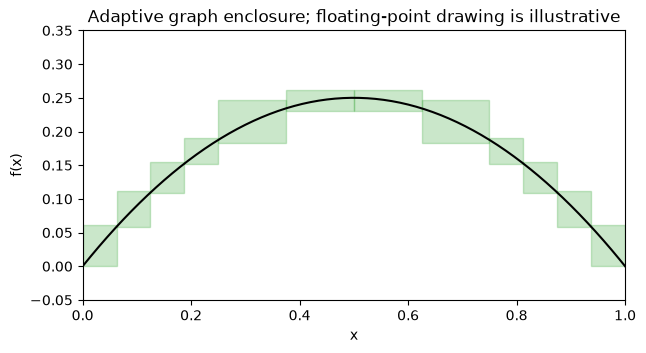

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for piece in result.pieces:
    X = piece.domain
    Y = piece.enclosure
    rectangle = Rectangle((float(X.lo), float(Y.lo)), float(X.width()), float(Y.width()),
                          facecolor="tab:green", edgecolor="tab:green", alpha=0.25)
    ax.add_patch(rectangle)
xs = np.linspace(0, 1, 201)
ax.plot(xs, xs*(1-xs), color="black")
ax.set(xlim=(0, 1), ylim=(-0.05, 0.35), xlabel="x", ylabel="f(x)",
       title="Adaptive graph enclosure; floating-point drawing is illustrative")
display(fig)
plt.close(fig)

## Inconclusive refinement still has a useful bound

A budget-limited result retains all current pieces. It reports a valid global
enclosure but does not claim that the requested local widths were achieved.
If a point domain still has a wide image, subdivision cannot help; arithmetic
precision or the evaluator itself must be reconsidered. General termination
cannot be promised for arbitrary evaluators and tolerances.

In [10]:
limited = adaptive_range(combined_polynomial, Interval(0, 1), "1/1000000", max_boxes=2)
print("Status:", limited.status)
print("Still a global enclosure:", limited.enclosure)
assert limited.status == "budget_exhausted"
assert Interval(0, "1/4").is_subset_of(limited.enclosure)

Status: budget_exhausted
Still a global enclosure: [0, 7/16]


## Recap and project preparation

Use algebraic structure, derivative bounds, monotonicity, and subdivision to
improve an enclosure. Keep the proof assumptions visible and report which
stopping criterion was actually met. Choosing a good method is part of the
algorithmic work, not merely increasing the number of arithmetic bits.

**Exit ticket:** explain why a budget-limited covering can remain rigorous,
while a list that silently drops difficult pieces cannot certify the whole domain.

**Reading:** Tucker §§3.2–3.3, pp. 55–59, with §3.1 on graph enclosures.
SIAM Challenge Chapter 4 is an optional later application. The
[mirror-trajectory project](../Doc/mirror_trajectory_project.md) will also need
careful domain/event decisions, beyond performing arithmetic with intervals.
Next: [automatic differentiation](08_automatic_differentiation.ipynb).